## Setup

In [1]:
import os
import json
import math
import random
import collections
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import Counter, defaultdict

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# output dirs
os.makedirs('embeddings', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## Data Loading

In [2]:
# load corpus files
def load_file(path):
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

def split_documents(text):
    # split on separator
    docs = [d.strip() for d in text.split('=' * 80) if d.strip()]
    return docs

def tokenize(text):
    # basic whitespace tokenize
    import re
    tokens = re.findall(r'[\u0600-\u06FF]+', text)
    return tokens

# load data
raw_text = load_file('raw.txt')
cleaned_text = load_file('cleaned.txt')
with open('Metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

raw_docs = split_documents(raw_text)
cleaned_docs = split_documents(cleaned_text)

print('Raw docs:', len(raw_docs))
print('Cleaned docs:', len(cleaned_docs))
print('Metadata entries:', len(metadata))

Raw docs: 300
Cleaned docs: 300
Metadata entries: 300


## Part 1 Word Embeddings

### 1.1 TF-IDF Weighting

In [3]:
# build vocabulary
VOCAB_SIZE = 10000

all_tokens = []
doc_tokens = []
for doc in cleaned_docs:
    toks = tokenize(doc)
    doc_tokens.append(toks)
    all_tokens.extend(toks)

freq = Counter(all_tokens)
vocab_words = [w for w, _ in freq.most_common(VOCAB_SIZE)]
word2idx = {w: i+1 for i, w in enumerate(vocab_words)}
word2idx['<UNK>'] = 0
idx2word = {v: k for k, v in word2idx.items()}

with open('embeddings/word2idx.json', 'w', encoding='utf-8') as f:
    json.dump(word2idx, f, ensure_ascii=False)

print('Vocab size:', len(word2idx))
print('Total tokens:', len(all_tokens))

Vocab size: 10001
Total tokens: 456492


In [4]:
# build term-document matrix
N = len(cleaned_docs)
V = len(word2idx)

# TF per document
tf_matrix = np.zeros((V, N), dtype=np.float32)
for j, toks in enumerate(doc_tokens):
    tok_count = Counter(toks)
    total = max(len(toks), 1)
    for w, c in tok_count.items():
        idx = word2idx.get(w, 0)
        tf_matrix[idx, j] = c / total

# DF per word
df = np.zeros(V, dtype=np.float32)
for j, toks in enumerate(doc_tokens):
    unique = set(word2idx.get(t, 0) for t in toks)
    for idx in unique:
        df[idx] += 1

# IDF
idf = np.log(N / (1 + df))

# TF-IDF matrix
tfidf_matrix = tf_matrix * idf[:, np.newaxis]

np.save('embeddings/tfidf_matrix.npy', tfidf_matrix)
print('TF-IDF matrix shape:', tfidf_matrix.shape)

TF-IDF matrix shape: (10001, 300)


In [5]:
# assign topic labels from metadata
TOPIC_KEYWORDS = {
    'Politics':    ['حکومت', 'وزیر', 'پارلیمان', 'انتخاب', 'سیاست', 'عمران', 'جمہوریت'],
    'Sports':      ['کرکٹ', 'کھیل', 'ٹیم', 'کھلاڑی', 'اسکور', 'میچ', 'ورلڈکپ'],
    'Economy':     ['معیشت', 'بجٹ', 'تجارت', 'بینک', 'افراط', 'روپیہ', 'ڈالر'],
    'International': ['اقوام', 'معاہدہ', 'غیر', 'یورپ', 'امریکہ', 'روس', 'یوکرین'],
    'Health':      ['صحت', 'ہسپتال', 'بیماری', 'دل', 'سیلاب', 'تعلیم', 'ویکسین']
}

doc_labels = []
for doc in cleaned_docs:
    scores = {cat: 0 for cat in TOPIC_KEYWORDS}
    toks = set(tokenize(doc))
    for cat, kws in TOPIC_KEYWORDS.items():
        scores[cat] = sum(1 for kw in kws if kw in toks)
    label = max(scores, key=scores.get)
    doc_labels.append(label)

print('Label distribution:', Counter(doc_labels))

Label distribution: Counter({'Politics': 107, 'International': 85, 'Health': 52, 'Sports': 46, 'Economy': 10})


In [6]:
# top-10 discriminative words per category
label_set = list(TOPIC_KEYWORDS.keys())
label2docs = defaultdict(list)
for j, lbl in enumerate(doc_labels):
    label2docs[lbl].append(j)

print('Top-10 words per category (TF-IDF):')
for cat in label_set:
    doc_indices = label2docs[cat]
    if not doc_indices:
        continue
    avg_tfidf = tfidf_matrix[:, doc_indices].mean(axis=1)
    top10_idx = np.argsort(avg_tfidf)[::-1][:10]
    top10_words = [idx2word.get(i, '<UNK>') for i in top10_idx]
    print(f'  {cat}: {top10_words}')

Top-10 words per category (TF-IDF):
  Politics: ['پولیس', 'اسرائیل', 'بلوچستان', 'حکومت', 'غزہ', 'شدت', 'حماس', 'سونی', 'بلوچ', 'خیبر']
  Sports: ['کرکٹ', 'میچ', 'ٹیم', 'بلے', 'بیٹ', 'غلاف', 'رنز', 'گرباز', 'چاند', 'سونیا']
  Economy: ['نوشین', 'سدرہ', 'ہیروئن', 'بیگ', 'روس', 'ارب', 'دولت', 'برکن', 'بریڈ', 'فورڈ']
  International: ['روس', 'یوکرین', 'ڈرون', 'ایران', 'اسرائیل', 'غزہ', 'روسی', 'حماس', 'ٹرمپ', 'چاند']
  Health: ['کینسر', 'بیماری', 'ڈاکٹر', 'علاج', 'دمہ', 'گلاکوما', 'دل', 'وائرس', 'اریجیت', 'پیٹرک']


### 1.2 Pointwise Mutual Information

In [7]:
# build co-occurrence matrix with window k=5
K_WINDOW = 5
TOP_VOCAB = min(5000, VOCAB_SIZE)  # reduce for memory

top_words = [w for w, _ in freq.most_common(TOP_VOCAB)]
top_w2i = {w: i for i, w in enumerate(top_words)}
TV = len(top_words)

cooc = np.zeros((TV, TV), dtype=np.float32)

for toks in doc_tokens:
    ids = [top_w2i[t] for t in toks if t in top_w2i]
    for i, center in enumerate(ids):
        start = max(0, i - K_WINDOW)
        end = min(len(ids), i + K_WINDOW + 1)
        for j in range(start, end):
            if i != j:
                cooc[center, ids[j]] += 1

print('Co-occurrence matrix shape:', cooc.shape)

Co-occurrence matrix shape: (5000, 5000)


In [8]:
# compute PPMI
total = cooc.sum()
row_sum = cooc.sum(axis=1, keepdims=True)
col_sum = cooc.sum(axis=0, keepdims=True)

# avoid division by zero
row_sum = np.maximum(row_sum, 1e-9)
col_sum = np.maximum(col_sum, 1e-9)

pmi = np.log2((cooc * total) / (row_sum * col_sum) + 1e-9)
ppmi = np.maximum(pmi, 0)

np.save('embeddings/ppmi_matrix.npy', ppmi)
print('PPMI matrix shape:', ppmi.shape)
print('Non-zero entries:', np.count_nonzero(ppmi))

PPMI matrix shape: (5000, 5000)
Non-zero entries: 864361


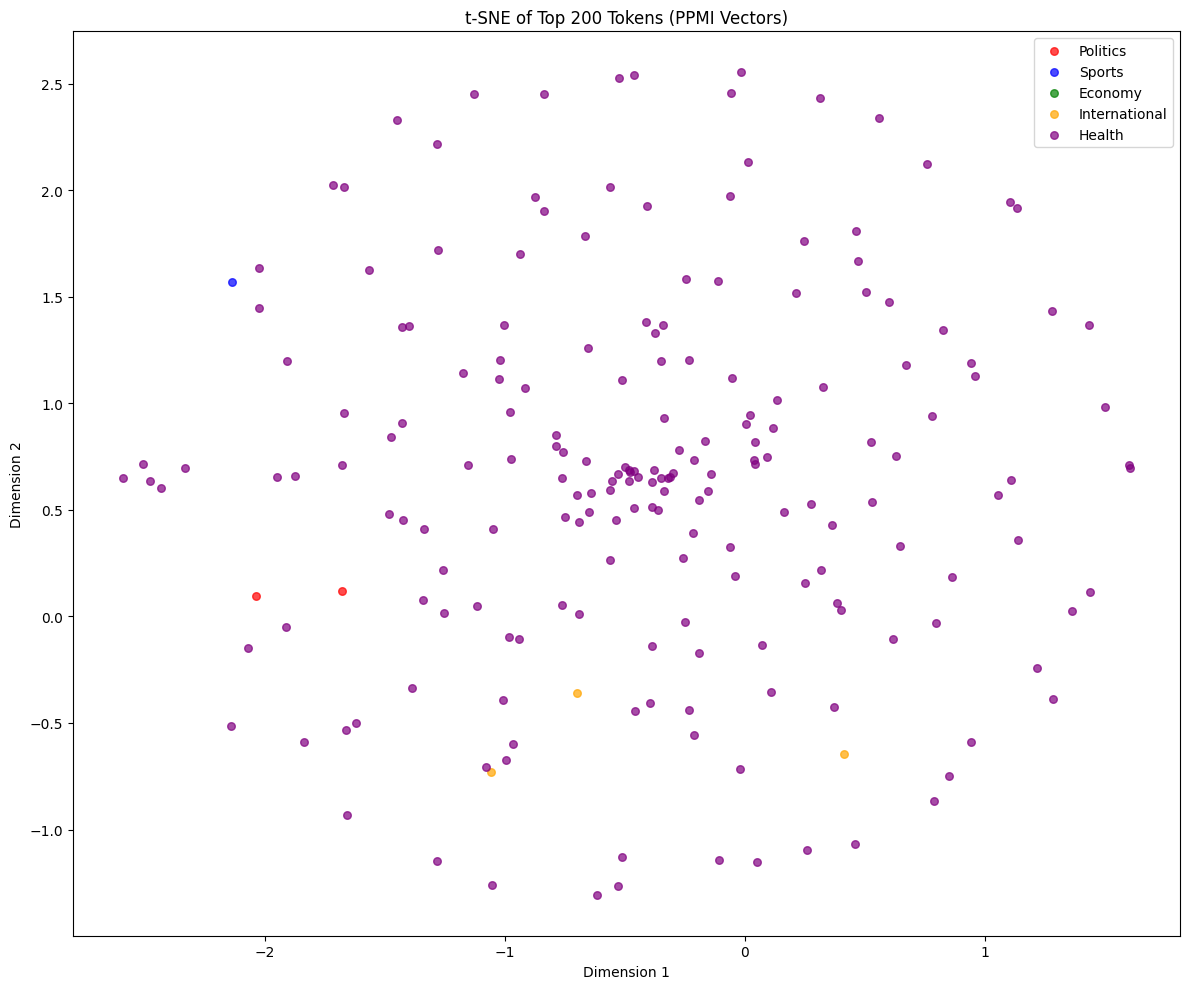

t-SNE plot saved


In [9]:
# t-SNE of top 200 tokens
N_TSNE = 200
tsne_vecs = ppmi[:N_TSNE]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_2d = tsne.fit_transform(tsne_vecs)

# assign categories to top words
cat_colors = {'Politics': 'red', 'Sports': 'blue', 'Economy': 'green',
              'International': 'orange', 'Health': 'purple'}

word_cats = []
for w in top_words[:N_TSNE]:
    assigned = 'Health'
    for cat, kws in TOPIC_KEYWORDS.items():
        if w in kws:
            assigned = cat
            break
    word_cats.append(assigned)

fig, ax = plt.subplots(figsize=(12, 10))
for cat, color in cat_colors.items():
    mask = [c == cat for c in word_cats]
    xs = tsne_2d[mask, 0]
    ys = tsne_2d[mask, 1]
    ax.scatter(xs, ys, c=color, label=cat, alpha=0.7, s=30)

ax.set_title('t-SNE of Top 200 Tokens (PPMI Vectors)')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.legend()
plt.tight_layout()
plt.savefig('embeddings/tsne_ppmi.png', dpi=100)
plt.show()
print('t-SNE plot saved')

In [10]:
# cosine similarity helper
def cosine_sim(a, b):
    a = a / (np.linalg.norm(a) + 1e-9)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)
    return b @ a

def nearest_neighbors_ppmi(query_word, matrix, w2i, i2w, topn=5):
    if query_word not in w2i:
        return []
    idx = w2i[query_word]
    sims = cosine_sim(matrix[idx], matrix)
    top = np.argsort(sims)[::-1][1:topn+1]
    return [(i2w[i], float(sims[i])) for i in top]

top_i2w = {i: w for w, i in top_w2i.items()}

query_words = ['پاکستان', 'حکومت', 'عدالت', 'معیشت', 'فوج',
               'صحت', 'تعلیم', 'آبادی', 'کرکٹ', 'انتخاب']

print('Top-5 PPMI neighbors:')
for qw in query_words:
    nn3 = nearest_neighbors_ppmi(qw, ppmi, top_w2i, top_i2w)
    print(f'  {qw}: {nn3}')

Top-5 PPMI neighbors:
  پاکستان: [('کے', 0.27608180046081543), ('انڈیا', 0.2648698389530182), ('کرکٹ', 0.2502172589302063), ('میں', 0.23449447751045227), ('پاکستانی', 0.2325802892446518)]
  حکومت: [('وزیر', 0.26076748967170715), ('کے', 0.24228772521018982), ('صوبائی', 0.2387477159500122), ('عبوری', 0.21641162037849426), ('جانب', 0.21590858697891235)]
  عدالت: [('کورٹ', 0.3167407810688019), ('پولیس', 0.22794677317142487), ('جج', 0.2138168066740036), ('اپیل', 0.21240399777889252), ('مقدمے', 0.21013781428337097)]
  معیشت: [('تیل', 0.16331566870212555), ('لاگت', 0.15944617986679077), ('بلوم', 0.14791817963123322), ('بہبود', 0.12864243984222412), ('برگ', 0.12794190645217896)]
  فوج: [('فوجی', 0.21144066751003265), ('اسرائیلی', 0.19304801523685455), ('کے', 0.187775656580925), ('یوکرین', 0.18701422214508057), ('افواج', 0.1855406016111374)]
  صحت: [('مند', 0.3185102343559265), ('ذہنی', 0.29582762718200684), ('ادارہ', 0.20132921636104584), ('یاب', 0.18810558319091797), ('وزارت', 0.1872481703758

### 2.1 Skip-gram Word2Vec

In [ ]:
# build training pairs
W2V_WINDOW = 5
W2V_DIM = 100
W2V_NEG = 10
W2V_LR = 0.001
W2V_EPOCHS = 5
W2V_BATCH = 512

# noise distribution P(w)^(3/4)
word_freqs = np.array([freq.get(idx2word.get(i, '<UNK>'), 0) for i in range(V)], dtype=np.float32)
noise_dist = word_freqs ** 0.75
noise_dist = noise_dist / noise_dist.sum()

print('Vocab:', V)
print('Noise dist sample:', noise_dist[:5])

In [ ]:
# generate skip-gram pairs
def make_skipgram_pairs(doc_tokens_list, w2i, window):
    pairs = []
    for toks in doc_tokens_list:
        ids = [w2i.get(t, 0) for t in toks]
        for i, center in enumerate(ids):
            start = max(0, i - window)
            end = min(len(ids), i + window + 1)
            for j in range(start, end):
                if i != j:
                    pairs.append((center, ids[j]))
    return pairs

print('Building pairs...')
sg_pairs = make_skipgram_pairs(doc_tokens, word2idx, W2V_WINDOW)
print('Total pairs:', len(sg_pairs))

In [ ]:


class SkipGramDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        c, o = self.pairs[idx]
        return torch.tensor(c, dtype=torch.long), torch.tensor(o, dtype=torch.long)


class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        # center and context matrices
        self.V = nn.Embedding(vocab_size, embed_dim)
        self.U = nn.Embedding(vocab_size, embed_dim)
        nn.init.uniform_(self.V.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.zeros_(self.U.weight)

    def forward(self, center, context, neg_samples):
        vc = self.V(center)               # (B, D)
        uo = self.U(context)              # (B, D)
        un = self.U(neg_samples)          # (B, K, D)

        # positive score
        pos = torch.sigmoid((uo * vc).sum(dim=1))       # (B,)
        pos_loss = -torch.log(pos + 1e-9).mean()

        # negative score
        neg = torch.sigmoid(-(un * vc.unsqueeze(1)).sum(dim=2))  # (B, K)
        neg_loss = -torch.log(neg + 1e-9).mean()

        return pos_loss + neg_loss

    def get_embeddings(self):
        return 0.5 * (self.V.weight.detach().cpu().numpy() +
                      self.U.weight.detach().cpu().numpy())

In [ ]:
def train_skipgram(pairs, vocab_size, noise_dist, embed_dim=100, epochs=5,
                   batch_size=512, lr=0.001, neg_samples=10, device=DEVICE):
    dataset = SkipGramDataset(pairs)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = SkipGramModel(vocab_size, embed_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    noise_tensor = torch.tensor(noise_dist, dtype=torch.float32)
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        steps = 0
        model.train()
        for center, context in loader:
            center = center.to(device)
            context = context.to(device)
            B = center.size(0)
            # sample negatives
            neg = torch.multinomial(noise_tensor, B * neg_samples, replacement=True)
            neg = neg.view(B, neg_samples).to(device)

            optimizer.zero_grad()
            loss = model(center, context, neg)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            steps += 1

            if steps % 500 == 0:
                print(f'  Epoch {epoch+1} step {steps} loss {total_loss/steps:.4f}')

        avg_loss = total_loss / max(steps, 1)
        loss_history.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs} avg loss {avg_loss:.4f}')

    return model, loss_history

print('Training Skip-gram...')
sg_model, sg_losses = train_skipgram(
    sg_pairs, V, noise_dist,
    embed_dim=W2V_DIM, epochs=W2V_EPOCHS,
    batch_size=W2V_BATCH, lr=W2V_LR, neg_samples=W2V_NEG
)

In [ ]:
# loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(sg_losses)+1), sg_losses, marker='o')
plt.title('Skip-gram Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('embeddings/w2v_loss.png', dpi=100)
plt.show()

# save embeddings
embeddings_w2v = sg_model.get_embeddings()
np.save('embeddings/embeddings_w2v.npy', embeddings_w2v)
print('Embeddings saved, shape:', embeddings_w2v.shape)

### 2.2 Evaluation

In [ ]:
# nearest neighbor helper for w2v
def nn_w2v(query, embeddings, w2i, i2w, topn=10):
    if query not in w2i:
        print(f'{query} not in vocab')
        return []
    idx = w2i[query]
    vec = embeddings[idx]
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    normed = embeddings / norms
    sims = normed @ (vec / (np.linalg.norm(vec) + 1e-9))
    top = np.argsort(sims)[::-1][1:topn+1]
    return [(i2w.get(i, '<UNK>'), float(sims[i])) for i in top]

# query words from assignment
query_words_w2v = ['پاکستان', 'حکومت', 'عدالت', 'معیشت', 'فوج',
                   'صحت', 'تعلیم', 'آبادی']

print('Top-10 Nearest Neighbors (Skip-gram C3):')
for qw in query_words_w2v:
    nn1 = nn_w2v(qw, embeddings_w2v, word2idx, idx2word, topn=10)
    print(f'\n  {qw}:')
    for w, s in nn1:
        print(f'    {w}: {s:.4f}')

In [ ]:
# analogy tests: a:b :: c:?
def analogy(a, b, c, embeddings, w2i, i2w, topn=3):
    if any(w not in w2i for w in [a, b, c]):
        return []
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    normed = embeddings / norms
    target = normed[w2i[b]] - normed[w2i[a]] + normed[w2i[c]]
    sims = normed @ target
    exclude = {w2i[a], w2i[b], w2i[c]}
    ranked = [(i, sims[i]) for i in np.argsort(sims)[::-1] if i not in exclude]
    return [(i2w.get(i, '<UNK>'), float(s)) for i, s in ranked[:topn]]

# 10 analogy tests
analogy_tests = [
    ('کراچی', 'سندھ', 'لاہور', 'پنجاب'),
    ('وزیر', 'حکومت', 'جج', 'عدالت'),
    ('کرکٹ', 'کھلاڑی', 'فٹبال', 'فٹبالر'),
    ('پاکستان', 'اسلام آباد', 'انڈیا', 'دہلی'),
    ('صدر', 'امریکہ', 'وزیراعظم', 'پاکستان'),
    ('اسکول', 'تعلیم', 'ہسپتال', 'صحت'),
    ('روپیہ', 'پاکستان', 'روپے', 'انڈیا'),
    ('فوج', 'جنرل', 'پولیس', 'افسر'),
    ('سردی', 'سرما', 'گرمی', 'گرما'),
    ('میچ', 'جیت', 'جنگ', 'فتح'),
]

print('Analogy Tests (a:b :: c:?):')
for a, b, c, expected in analogy_tests:
    result = analogy(a, b, c, embeddings_w2v, word2idx, idx2word)
    top_words = [r[0] for r in result]
    correct = expected in top_words
    print(f'  {a}:{b} :: {c}:? -> {top_words} (expected: {expected}) {"CORRECT" if correct else ""}')

### Four-Condition Comparison

In [ ]:
# C1: PPMI baseline (already computed)
# C2: Skip-gram on raw.txt
# C3: Skip-gram on cleaned.txt (already computed)
# C4: Skip-gram d=200 on cleaned.txt

# build raw doc tokens
raw_doc_tokens = [tokenize(doc) for doc in raw_docs]
raw_all_tokens = [t for toks in raw_doc_tokens for t in toks]
raw_freq = Counter(raw_all_tokens)
raw_vocab = [w for w, _ in raw_freq.most_common(VOCAB_SIZE)]
raw_w2i = {w: i+1 for i, w in enumerate(raw_vocab)}
raw_w2i['<UNK>'] = 0
raw_i2w = {v: k for k, v in raw_w2i.items()}
raw_V = len(raw_w2i)

# noise dist for raw
raw_word_freqs = np.array([raw_freq.get(raw_i2w.get(i, '<UNK>'), 0) for i in range(raw_V)], dtype=np.float32)
raw_noise = raw_word_freqs ** 0.75
raw_noise /= raw_noise.sum()

print('Building C2 pairs...')
c2_pairs = make_skipgram_pairs(raw_doc_tokens, raw_w2i, W2V_WINDOW)
print('C2 pairs:', len(c2_pairs))

In [ ]:
print('Training C2 (raw.txt)...')
c2_model, c2_losses = train_skipgram(c2_pairs, raw_V, raw_noise, embed_dim=100, epochs=5)
c2_emb = c2_model.get_embeddings()

print('\nTraining C4 (d=200)...')
c4_model, c4_losses = train_skipgram(sg_pairs, V, noise_dist, embed_dim=200, epochs=5)
c4_emb = c4_model.get_embeddings()

In [ ]:
# MRR computation
# manually labeled word pairs: (word, expected_neighbor)
eval_pairs = [
    ('پاکستان', 'اسلام آباد'), ('حکومت', 'وزیر'), ('کرکٹ', 'ٹیم'),
    ('صحت', 'ہسپتال'), ('تعلیم', 'اسکول'), ('فوج', 'فوجی'),
    ('معیشت', 'تجارت'), ('عدالت', 'جج'), ('انتخاب', 'ووٹ'),
    ('میڈیا', 'خبر'), ('یورپ', 'امریکہ'), ('کورونا', 'بیماری'),
    ('آبادی', 'شہر'), ('سیاست', 'جماعت'), ('بجٹ', 'معاشی'),
    ('کھلاڑی', 'کھیل'), ('وزیراعظم', 'حکومت'), ('پارلیمان', 'سینیٹ'),
    ('بینک', 'روپیہ'), ('صدر', 'حکومت'),
]

def compute_mrr(pairs, embeddings, w2i, i2w, topn=10):
    reciprocal_ranks = []
    for word, expected in pairs:
        nn2 = nn_w2v(word, embeddings, w2i, i2w, topn=topn)
        nn_words = [w for w, _ in nn2]
        if expected in nn_words:
            rank = nn_words.index(expected) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)
    return np.mean(reciprocal_ranks)

# C1 PPMI MRR
c1_mrr = compute_mrr(eval_pairs, ppmi, top_w2i, top_i2w)
# C2 raw
c2_mrr = compute_mrr(eval_pairs, c2_emb, raw_w2i, raw_i2w)
# C3 cleaned
c3_mrr = compute_mrr(eval_pairs, embeddings_w2v, word2idx, idx2word)
# C4 d=200
c4_mrr = compute_mrr(eval_pairs, c4_emb, word2idx, idx2word)

print('MRR Results:')
print(f'  C1 PPMI:           {c1_mrr:.4f}')
print(f'  C2 SG raw.txt:     {c2_mrr:.4f}')
print(f'  C3 SG cleaned.txt: {c3_mrr:.4f}')
print(f'  C4 SG d=200:       {c4_mrr:.4f}')

In [ ]:
# top-5 neighbors per condition for 5 query words
eval_queries = ['پاکستان', 'حکومت', 'کرکٹ', 'صحت', 'تعلیم']

print('Top-5 neighbors per condition:')
for qw in eval_queries:
    print(f'\n{qw}:')
    c1 = [w for w, _ in nearest_neighbors_ppmi(qw, ppmi, top_w2i, top_i2w, topn=5)]
    c2 = [w for w, _ in nn_w2v(qw, c2_emb, raw_w2i, raw_i2w, topn=5)]
    c3 = [w for w, _ in nn_w2v(qw, embeddings_w2v, word2idx, idx2word, topn=5)]
    c4 = [w for w, _ in nn_w2v(qw, c4_emb, word2idx, idx2word, topn=5)]
    print(f'  C1 PPMI:   {c1}')
    print(f'  C2 SG raw: {c2}')
    print(f'  C3 SG cln: {c3}')
    print(f'  C4 SG d200:{c4}')
